# Transfer Learning - MobileNetV2 Image Classification

This project applies Transfer Learning using a pretrained MobileNetV2 model to classify CIFAR-10 images. The notebook covers preprocessing, transfer learning, training, evaluation, and error analysis.

## 1. Import Required Libraries

Import all required libraries.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers,models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
tf.keras.utils.set_random_seed(42)

import warnings

warnings.filterwarnings(
    "ignore",
    message="`shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset.*"
)

## 2. Load Dataset

Load the CIFAR-10 dataset.

In [9]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()
classes=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

## 3. Explore Dataset

Visualize sample images.

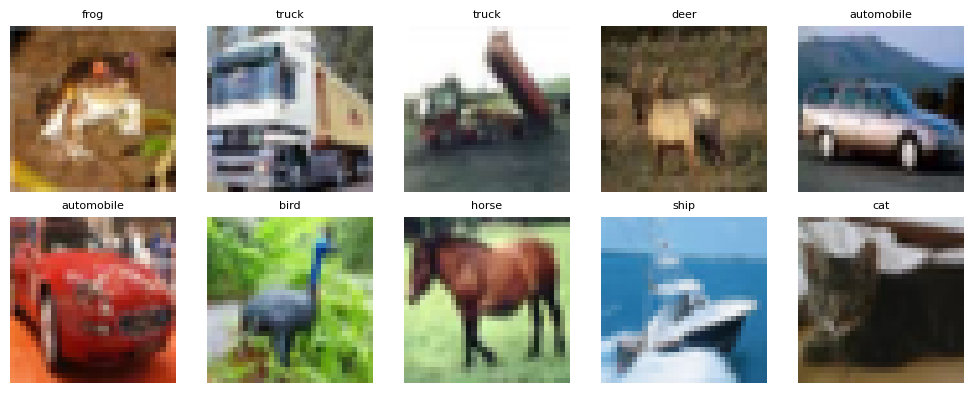

In [10]:
fig,ax=plt.subplots(2,5,figsize=(10,4))
for i,a in enumerate(ax.ravel()):
 a.imshow(x_train[i]);a.set_title(classes[y_train[i][0]],fontsize=8);a.axis('off')
plt.tight_layout();plt.show()

## 4. Create Validation Set

Create a stratified validation split.

In [11]:
x_train,x_val,y_train,y_val=train_test_split(x_train,y_train,test_size=0.2,stratify=y_train,random_state=42)

## 5. Preprocess Images

Resize images and apply MobileNetV2 preprocessing.

In [12]:
IMG_SIZE = 96
BATCH_SIZE = 128

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(len(x_train), seed=42)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


## 6. Build Transfer Learning Model

Freeze the pretrained backbone and add a custom classifier.

In [13]:
base=MobileNetV2(weights='imagenet',include_top=False,input_shape=(96,96,3))
base.trainable=False
model=models.Sequential([base,layers.GlobalAveragePooling2D(),layers.Dropout(0.3),layers.Dense(128,activation='relu'),layers.Dropout(0.3),layers.Dense(10,activation='softmax')])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Train the Model

Train the custom classifier.

In [14]:
early=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early]
)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 378ms/step - accuracy: 0.7477 - loss: 0.7546 - val_accuracy: 0.8424 - val_loss: 0.4561
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 132s 422ms/step - accuracy: 0.8183 - loss: 0.5317 - val_accuracy: 0.8512 - val_loss: 0.4287
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.8355 - loss: 0.4809 - val_accuracy: 0.8588 - val_loss: 0.4034
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 275ms/step - accuracy: 0.8432 - loss: 0.4531 - val_accuracy: 0.8633 - val_loss: 0.3978
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 243ms/step - accuracy: 0.8496 - loss: 0.4296 - val_accuracy: 0.8662 - val_loss: 0.3854
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 242ms/step - accuracy: 0.8553 - loss: 0.4106 - val_accuracy: 0.8629 - val_loss: 0.3848
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 239ms/step - accuracy: 0.8626 - loss: 0.3971 - val_accuracy: 0.8677 - val_loss: 0.3729
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 241ms/step - accuracy: 0.8644 - loss:

## 8. Training Curves

Plot learning curves.

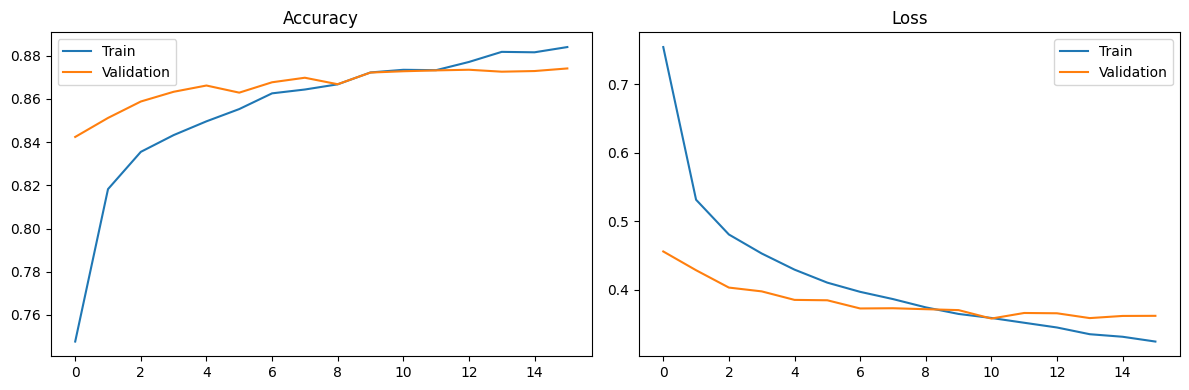

In [15]:
plt.figure(figsize=(12,4))
plt.subplot(121);plt.plot(history.history['accuracy']);plt.plot(history.history['val_accuracy']);plt.legend(['Train','Validation']);plt.title('Accuracy')
plt.subplot(122);plt.plot(history.history['loss']);plt.plot(history.history['val_loss']);plt.legend(['Train','Validation']);plt.title('Loss')
plt.tight_layout();plt.show()

## 9. Evaluate Model

Evaluate on the test set.

In [16]:
test_loss,test_acc=model.evaluate(test_ds,verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

pred_probs=model.predict(test_ds,verbose=0)
pred=np.argmax(pred_probs,axis=1)


Test Accuracy: 0.8735


## 10. Classification Report

Generate classification metrics.

In [17]:
print(classification_report(y_test,pred,target_names=classes))

              precision    recall  f1-score   support

    airplane       0.89      0.87      0.88      1000
  automobile       0.94      0.94      0.94      1000
        bird       0.89      0.81      0.85      1000
         cat       0.76      0.77      0.76      1000
        deer       0.83      0.86      0.85      1000
         dog       0.83      0.80      0.81      1000
        frog       0.87      0.93      0.90      1000
       horse       0.89      0.89      0.89      1000
        ship       0.90      0.95      0.92      1000
       truck       0.92      0.92      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



## 11. Confusion Matrix

Visualize model predictions.

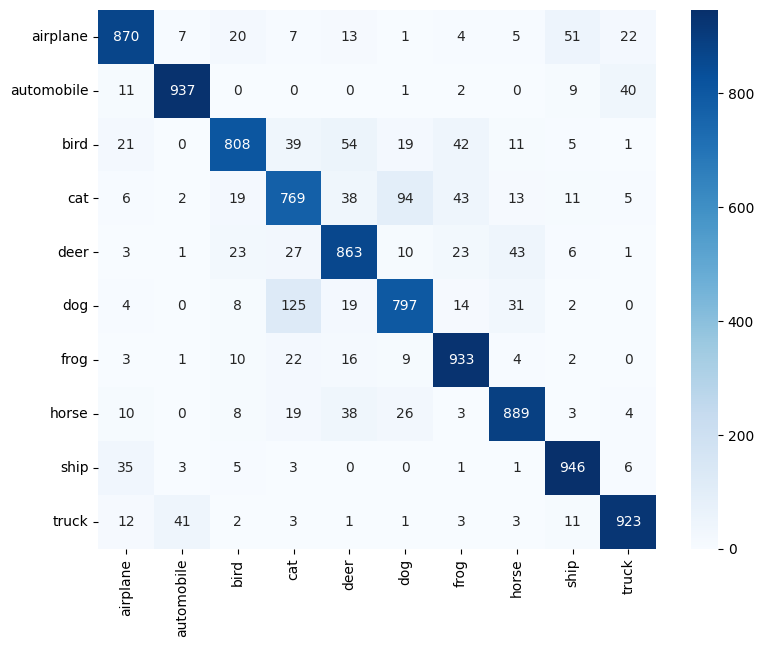

In [18]:
cm=confusion_matrix(y_test,pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=classes,yticklabels=classes)
plt.show()

## 12. Sample Predictions

Display predictions.

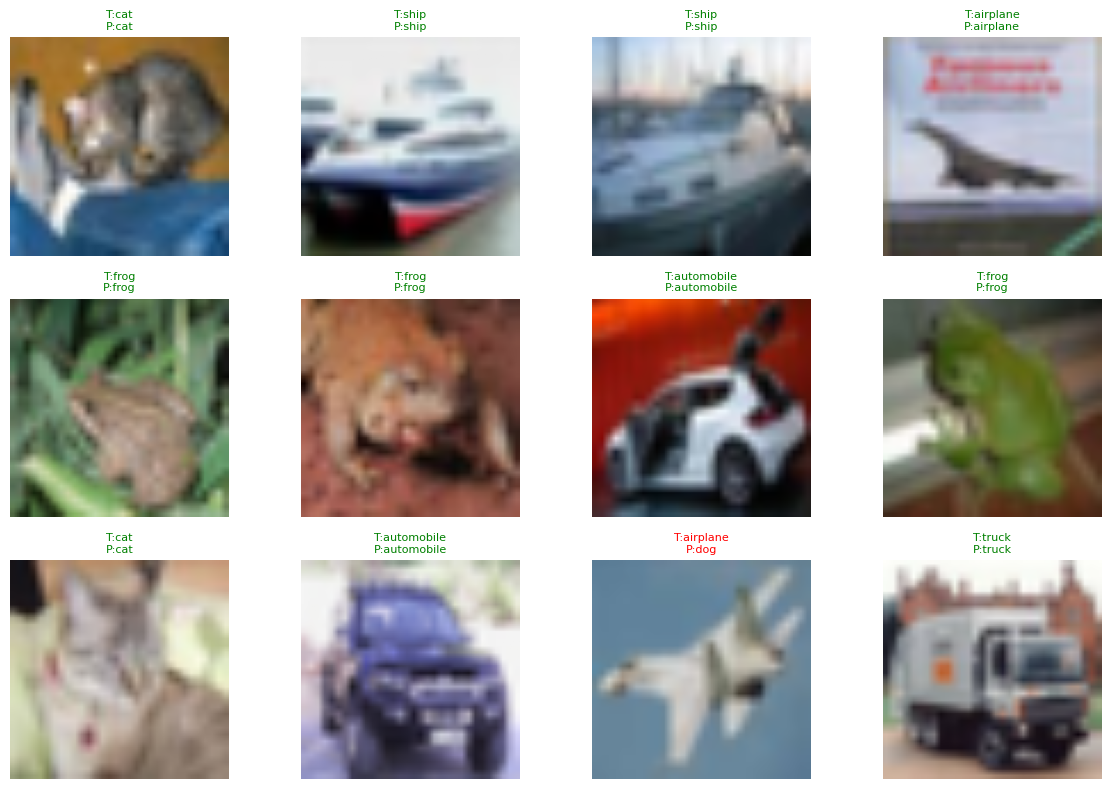

In [21]:
plt.figure(figsize=(12,8))
for images,labels in test_ds.take(1):
    images=((images+1)/2).numpy()
    labels=labels.numpy().flatten()
    for i in range(12):
        plt.subplot(3,4,i+1)
        plt.imshow(np.clip(images[i],0,1))
        color='green' if pred[i]==labels[i] else 'red'
        plt.title(f"T:{classes[labels[i]]}\nP:{classes[pred[i]]}",fontsize=8,color=color)
        plt.axis('off')
plt.tight_layout()
plt.show()


## 13. Misclassified Examples

Inspect incorrect predictions.

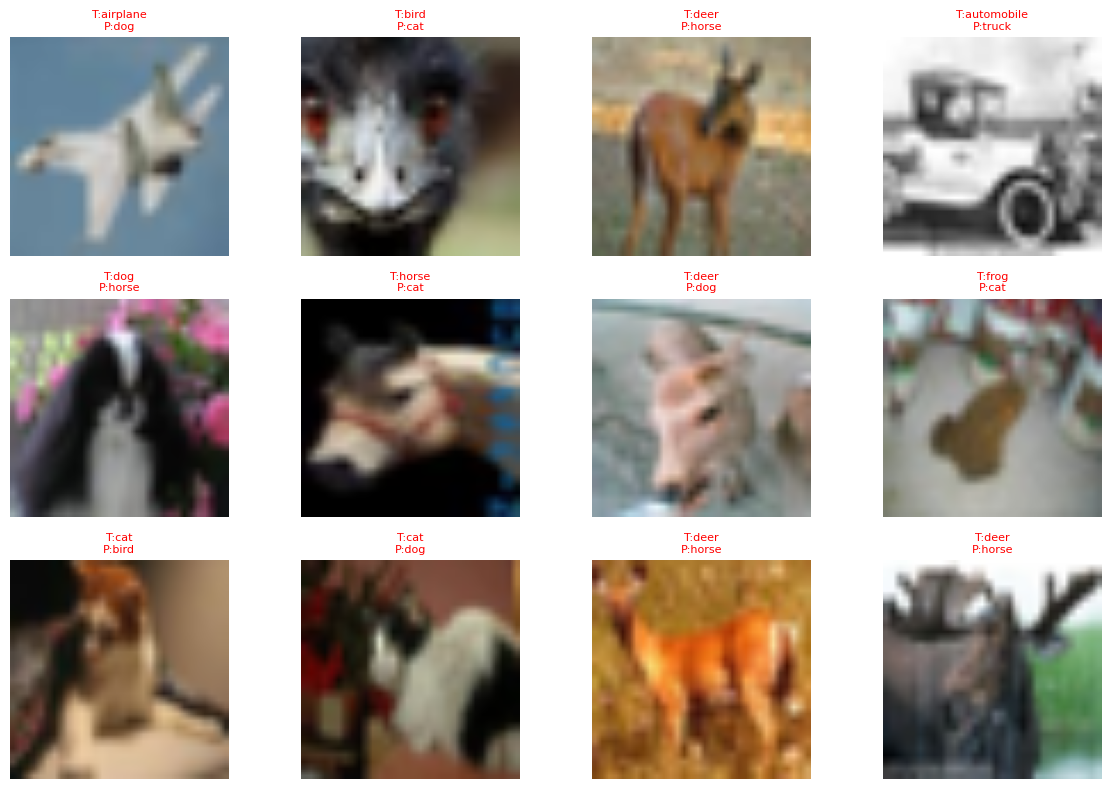

In [23]:
all_images=[]
all_labels=[]
for images,labels in test_ds:
    all_images.append(((images+1)/2).numpy())
    all_labels.append(labels.numpy().flatten())
all_images=np.concatenate(all_images)
all_labels=np.concatenate(all_labels)

mis=np.where(pred!=all_labels)[0][:12]

plt.figure(figsize=(12,8))
for j,i in enumerate(mis):
    plt.subplot(3,4,j+1)
    plt.imshow(np.clip(all_images[i],0,1))
    plt.title(f"T:{classes[all_labels[i]]}\nP:{classes[pred[i]]}",fontsize=8,color='red')
    plt.axis('off')
plt.tight_layout()
plt.show()


## 14. Key Findings

The transfer learning model achieved a **test accuracy of 87.35%**, representing a substantial improvement over the custom CNN trained from scratch on the same CIFAR-10 dataset. This demonstrates the effectiveness of leveraging ImageNet-trained feature representations, even when the target dataset consists of relatively small 32×32 images.

Classification performance was strongest for structurally distinct classes such as **automobiles, trucks, ships, and frogs**, where both precision and recall exceeded 0.90 in most cases. In contrast, classes such as **cats** and **dogs** remained the most challenging due to their greater intra-class variability and visual similarity, resulting in comparatively lower precision and recall.

The training and validation curves remained closely aligned throughout training, indicating that freezing the pretrained MobileNetV2 backbone provided strong generalization while minimizing overfitting. Overall, the experiment highlights the practical advantage of transfer learning over training a CNN from scratch for moderate-sized image classification tasks.

## 15. Conclusion

This project implemented transfer learning using a pretrained MobileNetV2 network as a fixed feature extractor for CIFAR-10 image classification. By replacing the original classification head with a task-specific classifier, the model effectively transferred high-level visual representations learned from ImageNet to a new dataset.

The final model achieved **87.35%** test accuracy, improving upon the previous custom CNN by approximately **9.5 percentage points** while maintaining stable training behaviour and good generalization. These results demonstrate that pretrained convolutional features provide a considerably stronger baseline than training a convolutional network from random initialization, making transfer learning a practical and effective approach for image classification problems with limited computational resources.